# Metrics and Evaluation - California Housing Dataset

In [3]:
from sklearn.datasets import fetch_california_housing

x, y = fetch_california_housing(return_X_y=True, as_frame=True)

x.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [4]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


<Axes: xlabel='MedHouseVal', ylabel='Count'>

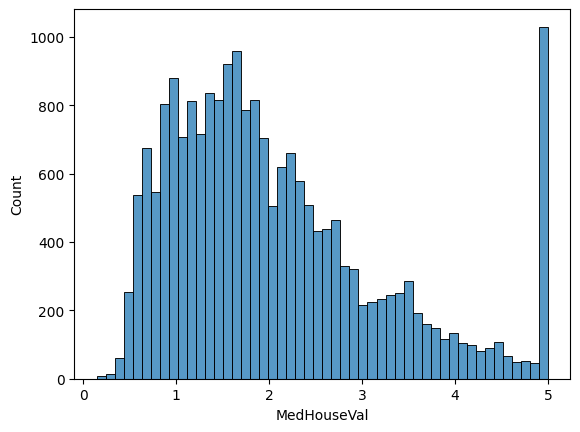

In [5]:
import seaborn as sns

sns.histplot(y, bins=50)

In [7]:
from sklearn.model_selection import train_test_split

x_train, x_testval, y_train, y_testval = train_test_split(x, y, test_size=0.2, random_state=42)
x_test, x_val, y_test, y_val = train_test_split(x_testval, y_testval, test_size=0.5, random_state=42)

Se realizó la separación de las columnas de latitud y longitud de los demás valores, por otro lado se realizo la eliminación de los outliers del conjunto de train mediante el IQR con 1.5, solo sobre x_tran evitando el data leakage, por otro lado  se calcularon la media y desviación estándar del train separado para usarlos en scaling y se convirtieron los conjuntos en tensores de PyTorch.

In [57]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

cols_procesar = [c for c in x_train.columns if c not in ["Latitude", "Longitude"]]
cols_latlon   = ["Latitude", "Longitude"]


Q1 = x_train[cols_procesar].quantile(0.25)
Q3 = x_train[cols_procesar].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower = torch.tensor(lower_bound.values, dtype=torch.float32)
upper = torch.tensor(upper_bound.values, dtype=torch.float32)

mean = torch.tensor(x_train[cols_procesar].mean().values, dtype=torch.float32)
std  = torch.tensor(x_train[cols_procesar].std().values,  dtype=torch.float32)

X_train_t = torch.tensor(x_train.values, dtype=torch.float32)
X_test_t  = torch.tensor(x_test.values,  dtype=torch.float32)
X_val_t   = torch.tensor(x_val.values,   dtype=torch.float32)

y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_t  = torch.tensor(y_test.values,  dtype=torch.float32).view(-1, 1)
y_val_t   = torch.tensor(y_val.values,   dtype=torch.float32).view(-1, 1)

Se crearon dos capas de procesamiento como nn.Module  ScalingLayer aplica standard scaling utilizando los bufers para almacenar la media y desviación  del train, PreprocessingLayer escala las columnas con scaling layer y concatena Latitude y Longitude sin modificar, HousingData setse encarga de cargar datos con diferentes batches en el train.

In [58]:
class ScalingLayer(nn.Module):
    def __init__(self, mean, std, lower, upper):
        super().__init__()
        self.register_buffer('mean',  mean)
        self.register_buffer('std',   std)
        self.register_buffer('lower', lower)
        self.register_buffer('upper', upper)

    def forward(self, X):
        X = torch.clamp(X, self.lower, self.upper)
        return (X - self.mean) / (self.std + 1e-8)


class PreprocessingLayer(nn.Module):
    def __init__(self, mean, std, lower, upper):
        super().__init__()
        self.scaler = ScalingLayer(mean, std, lower, upper)

    def forward(self, x_main, x_rest):
        return torch.cat([
            self.scaler(x_main),
            x_rest
        ], dim=1)

In [59]:
class HousingDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [60]:
from tqdm import tqdm

def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs):
    training_losses = []
    validation_losses = []

    patience = 5
    epocas_sin_mejora = 0

    for epoch in range(_num_epochs):
        _model.train()
        running_loss = 0.0

        for X_batch, y_batch in tqdm(_train_loader, desc=f"Epoch {epoch+1}/{_num_epochs}"):
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()

            running_loss += loss.item() * X_batch.size(0)

        epoch_train_loss = running_loss / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for X_val, y_val in _val_loader:
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)

        epoch_val_loss = val_loss / len(_val_loader.dataset)

        print(f"epoch {epoch+1} loss: {epoch_train_loss:.4f} (train) | loss: {epoch_val_loss:.4f} (val)")

        training_losses.append(epoch_train_loss)
        validation_losses.append(epoch_val_loss)

        if len(validation_losses) > 1 and epoch_val_loss >= validation_losses[-2]:
            epocas_sin_mejora += 1
            if epocas_sin_mejora >= patience:
                print("Stopping training: no improvement for 3 epochs.")
                break
        else:
            epocas_sin_mejora = 0

    return training_losses, validation_losses




In [61]:
idx_main = [i for i, c in enumerate(x_train.columns) if c not in cols_latlon]
idx_rest = [i for i, c in enumerate(x_train.columns) if c in cols_latlon]

class HousingModel(nn.Module):
    def __init__(self, mean, std, lower, upper, network):
        super().__init__()
        self.preprocessing = PreprocessingLayer(mean, std, lower, upper)
        self.network = network

    def forward(self, x):
        x_main = x[:, idx_main]
        x_rest = x[:, idx_rest]
        x = self.preprocessing(x_main, x_rest)
        return self.network(x)

In [62]:
train_dataset = HousingDataset(X_train_t, y_train_t)
val_dataset   = HousingDataset(X_val_t,   y_val_t)
test_dataset  = HousingDataset(X_test_t,  y_test_t)

In [63]:
model = HousingModel(mean, std, lower, upper, nn.Sequential(
    nn.Linear(8, 128), nn.ReLU(),
    nn.Linear(128, 64), nn.ReLU(),
    nn.Linear(64, 32), nn.ReLU(),
    nn.Linear(32, 1)
))

criterion  = nn.MSELoss()
optimizer  = torch.optim.Adam(model.parameters(), lr=0.001)
num_epochs = 50
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size)

train_losses, val_losses = train(model, train_loader, val_loader, criterion, optimizer, num_epochs)

Epoch 1/50: 100%|██████████| 201/201 [00:00<00:00, 319.12it/s]


epoch 1 loss: 1.2048 (train) | loss: 1.2779 (val)


Epoch 2/50: 100%|██████████| 201/201 [00:00<00:00, 439.80it/s]


epoch 2 loss: 0.6989 (train) | loss: 0.5526 (val)


Epoch 3/50: 100%|██████████| 201/201 [00:00<00:00, 429.94it/s]


...

epoch 48 loss: 0.4042 (train) | loss: 0.4241 (val)


Epoch 49/50: 100%|██████████| 201/201 [00:00<00:00, 436.05it/s]


epoch 49 loss: 0.3994 (train) | loss: 0.4362 (val)


Epoch 50/50: 100%|██████████| 201/201 [00:00<00:00, 406.06it/s]


epoch 50 loss: 0.4077 (train) | loss: 0.4316 (val)


In [64]:
model2 = HousingModel(mean, std, lower, upper, nn.Sequential(
    nn.Linear(8, 64), nn.ReLU(),
    nn.Linear(64, 32), nn.ReLU(),
    nn.Linear(32, 1)
))

criterion2  = nn.MSELoss()
optimizer2  = torch.optim.Adam(model2.parameters(), lr=0.001)
num_epochs2 = 50
batch_size2 = 128

train_loader2 = DataLoader(train_dataset, batch_size=batch_size2, shuffle=True)
val_loader2   = DataLoader(val_dataset,   batch_size=batch_size2)

train_losses2, val_losses2 = train(model2, train_loader2, val_loader2, criterion2, optimizer2, num_epochs2)

Epoch 1/50: 100%|██████████| 101/101 [00:00<00:00, 419.66it/s]


epoch 1 loss: 2.2414 (train) | loss: 1.1530 (val)


Epoch 2/50: 100%|██████████| 101/101 [00:00<00:00, 407.53it/s]


epoch 2 loss: 0.9135 (train) | loss: 0.9317 (val)


Epoch 3/50: 100%|██████████| 101/101 [00:00<00:00, 415.94it/s]


...

epoch 48 loss: 0.4094 (train) | loss: 0.4401 (val)


Epoch 49/50: 100%|██████████| 101/101 [00:00<00:00, 254.59it/s]


epoch 49 loss: 0.4178 (train) | loss: 0.5154 (val)


Epoch 50/50: 100%|██████████| 101/101 [00:00<00:00, 250.02it/s]


epoch 50 loss: 0.4188 (train) | loss: 0.4886 (val)


In [65]:
model3 = HousingModel(mean, std, lower, upper, nn.Sequential(
    nn.Linear(8, 128), nn.ReLU(),
    nn.Linear(128, 64), nn.ReLU(),
    nn.Linear(64, 32), nn.ReLU(),
    nn.Linear(32, 1)
))

criterion3  = nn.MSELoss()
optimizer3  = torch.optim.Adam(model3.parameters(), lr=0.0001)
num_epochs3 = 50
batch_size3 = 32

train_loader3 = DataLoader(train_dataset, batch_size=batch_size3, shuffle=True)
val_loader3   = DataLoader(val_dataset,   batch_size=batch_size3)

train_losses3, val_losses3 = train(model3, train_loader3, val_loader3, criterion3, optimizer3, num_epochs3)

Epoch 1/50: 100%|██████████| 402/402 [00:00<00:00, 491.25it/s]


epoch 1 loss: 1.1451 (train) | loss: 1.2232 (val)


Epoch 2/50: 100%|██████████| 402/402 [00:00<00:00, 496.86it/s]


epoch 2 loss: 1.0029 (train) | loss: 1.0013 (val)


Epoch 3/50: 100%|██████████| 402/402 [00:00<00:00, 504.82it/s]


...

epoch 48 loss: 0.4127 (train) | loss: 0.4450 (val)


Epoch 49/50: 100%|██████████| 402/402 [00:00<00:00, 467.06it/s]


epoch 49 loss: 0.4153 (train) | loss: 0.4599 (val)


Epoch 50/50: 100%|██████████| 402/402 [00:00<00:00, 479.67it/s]

epoch 50 loss: 0.4107 (train) | loss: 0.4520 (val)


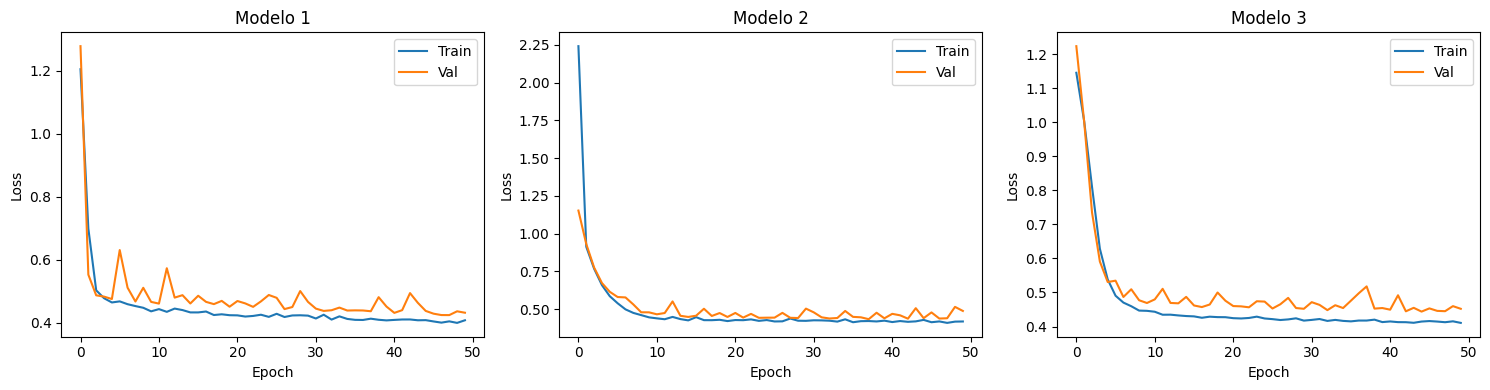

Test MAE Modelo 1: 0.4554 | MSE: 0.4367
Test MAE Modelo 2: 0.4807 | MSE: 0.4950
Test MAE Modelo 3: 0.4794 | MSE: 0.4638


In [66]:
import matplotlib.pyplot as plt

def get_test_metrics(model, test_data):
    model.eval()
    with torch.no_grad():
        outputs = model(test_data.X)
        mae = torch.mean(torch.abs(outputs - test_data.y)).item()
        mse = torch.mean((outputs - test_data.y) ** 2).item()
    return mae, mse

mae1, mse1 = get_test_metrics(model,  test_dataset)
mae2, mse2 = get_test_metrics(model2, test_dataset)
mae3, mse3 = get_test_metrics(model3, test_dataset)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (t_losses, v_losses, title) in enumerate([
    (train_losses,  val_losses,  "Modelo 1"),
    (train_losses2, val_losses2, "Modelo 2"),
    (train_losses3, val_losses3, "Modelo 3"),
]):
    axes[i].plot(t_losses, label='Train')
    axes[i].plot(v_losses, label='Val')
    axes[i].set_title(title)
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Loss')
    axes[i].legend()

plt.tight_layout()
plt.show()

print(f"Test MAE Modelo 1: {mae1:.4f} | MSE: {mse1:.4f}")
print(f"Test MAE Modelo 2: {mae2:.4f} | MSE: {mse2:.4f}")
print(f"Test MAE Modelo 3: {mae3:.4f} | MSE: {mse3:.4f}")

In [67]:

if mae1 <= mae2 and mae1 <= mae3:
    best_model = model
    best_name  = "Modelo 1"
elif mae2 <= mae3:
    best_model = model2
    best_name  = "Modelo 2"
else:
    best_model = model3
    best_name  = "Modelo 3"

print(f"Mejor modelo: {best_name}")


mae_val, mse_val = get_test_metrics(best_model, test_dataset)
print(f"Val MAE: {mae_val:.4f} | MSE: {mse_val:.4f}")

Mejor modelo: Modelo 1
Val MAE: 0.4554 | MSE: 0.4367


En esta actividad se realizó un preprocesamiento por medio de PyTorch en el módulo nn.Module usando scaling y eliminar outliers  se realizó una predicción de los precios de casas de CaliforniaHousing.
El modelo 1 presentó los mejores resultados.
